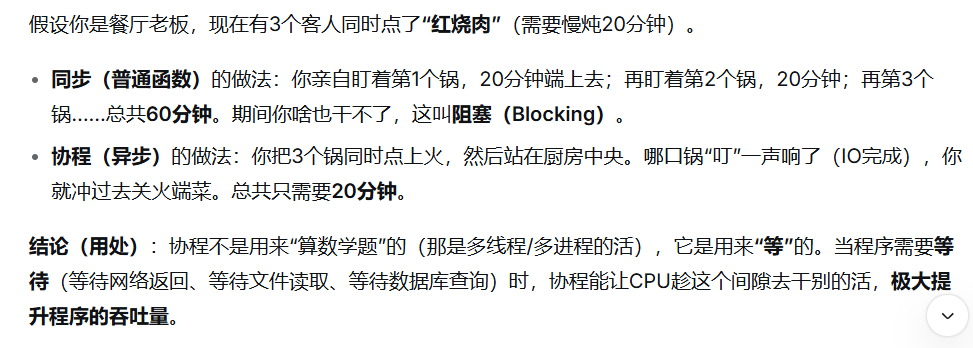
*函数级并发*

1.async:定义可以暂停的函数,普通的 def 是一口气干到底。async def 定义了一个协程函数，中途可以暂停,让cpu做其他事情

In [1]:
import asyncio
# 这是一个协程函数（定义菜谱），调用它并不会开始做菜
async def cook_dish(dish_name):
    print(f"开始炖 {dish_name}")
    # 模拟炖菜等待的过程（等20分钟）
    await asyncio.sleep(20)
    print(f"{dish_name} 炖好了！")
    return f"一碗{dish_name}"

2.await:表示这里先等待,让出cpu干其他事情
**await只能出现在async函数中**

3.asyncio.create_task():将函数执行包装为task,以待并发

In [2]:
async def main():
    # 同时点三个火（创建任务），但此时还没真正开始等
    task1 = asyncio.create_task(cook_dish("红烧肉1号"))
    task2 = asyncio.create_task(cook_dish("红烧肉2号"))
    task3 = asyncio.create_task(cook_dish("红烧肉3号"))

    #另一种写法,创建tasks列表,直接传入
    #tasks=[asyncio.create_task(cook_dish(f"红烧肉{i}号")) for i in range(3)]
    #results=await asyncio.gather(*tasks)

    # 现在站在厨房中间等所有锅响（并发等待）
    results = await asyncio.gather(task1, task2, task3)
    print(f"全部完成：{results}")

4.asyncio.run():让task开始运行

In [ ]:
# 程序的唯一入口
if __name__ == "__main__":
    asyncio.run(main())

**协程进阶**

1.异步上下文管理器:用于需要释放资源的操作（如数据库连接、文件）。相当于“自动开关煤气”。

In [ ]:
async with aiofiles.open('log.txt', 'r') as f:
    content = await f.read()

2.异步迭代器 (async for)：用于分页拉取数据（如爬取多页API）

In [ ]:
async for page in fetch_all_pages():
    print(page)